# Neural Networks from Scratch



<img src="./figs/Gemini_Generated_Image_3zbujj3zbujj3zbu.png" width="800"/>



## Model architecture
We are building a basic deep neural network with 3 layers in total: 1 input layer, 1 hidden layers and 1 output layer. All layers will be fully connected. We implement ReLU and sigmoid activation functions. SGD and Momentum optimizer are available.

Let's try to define the layers in an exact way.

1. Input layer: In this layer, we input our dataset, consisting of 28x28 images. We flatten these images into one array with $28×28=784$ elements. This means our input layer will have 784 nodes.
2. Hidden layer: In this layer, we have decided to reduce the number of nodes from 784 in the input layer to 64 nodes.
3. Output layer: In this layer, we are reducing the 64 nodes to a total of 10 nodes, so that we can evaluate the nodes against the label. This label is received in the form of an array with 10 elements, where one of the elements is 1, while the rest is 0.

In [32]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import time

## Helper functions

In [33]:
# Helper functions
def show_images(image, num_row=2, num_col=5):
    """Display a grid of MNIST images"""
    image_size = int(np.sqrt(image.shape[-1]))
    image = np.reshape(image, (image.shape[0], image_size, image_size))
    fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col, 2*num_row))
    for i in range(num_row*num_col):
        ax = axes[i//num_col, i%num_col]
        ax.imshow(image[i], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
def one_hot(x, k, dtype=np.float32):
    """Create a one-hot encoding of x of size k"""
    # Convert pandas Series to numpy array if needed
    x = np.asarray(x)
    return np.array(x[:, None] == np.arange(k), dtype)

## Dataset preparation
We will use [MNIST dataset](http://yann.lecun.com/exdb/mnist/) to demo how to build a neural network. 

In [34]:
# Load data
mnist_data = fetch_openml("mnist_784")
x = mnist_data["data"]
y = mnist_data["target"]

# Convert pandas to numpy for compatibility
x = np.asarray(x)
y = np.asarray(y)

# Normalize - convert to float first to avoid casting issues
x = x.astype(np.float32)
x /= 255.0

# One-hot encode labels
num_labels = 10
examples = y.shape[0]
y_new = one_hot(y.astype('int32'), num_labels)

# Split into train and test sets
train_size = 60000
test_size = x.shape[0] - train_size
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y_new[:train_size], y_new[train_size:]

# Shuffle training data
shuffle_index = np.random.permutation(train_size)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]

Training data: (60000, 784) (60000, 10)
Test data: (10000, 784) (10000, 10)


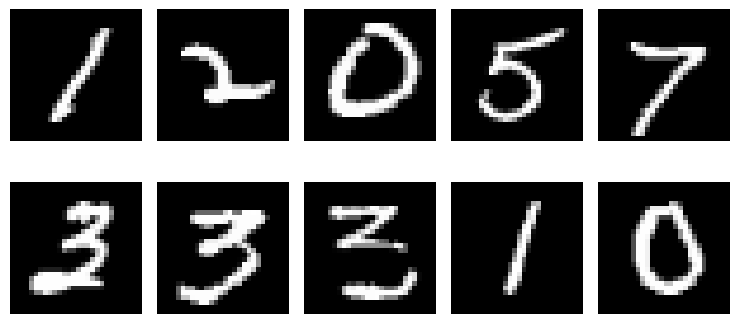

In [35]:
print("Training data: {} {}".format(x_train.shape, y_train.shape))
print("Test data: {} {}".format(x_test.shape, y_test.shape))
show_images(x_train)

## Network Initialization

When we create a `DeepNeuralNetwork` object with the architecture `[784, 64, 10]`:
- **Input layer**: 784 nodes (28×28 pixel images flattened)
- **Hidden layer**: 64 nodes (learns intermediate features)
- **Output layer**: 10 nodes (one for each digit 0-9)

### Weight Initialization Strategy

We use **He initialization**: scale weights by $\sqrt{1/n}$ where $n$ is the input size.

**Why?** This prevents:
- **Vanishing gradients**: Network can't learn (gradients → 0)
- **Exploding gradients**: Network becomes unstable (values → ∞)

The initialization happens automatically when creating the network.

## Forward Pass (Prediction)

The forward pass runs data through the network layer by layer:

**Layer 1 (Hidden):**
- Compute: $Z_1 = W_1 \cdot X + b_1$
- Activate: $A_1 = \text{activation}(Z_1)$ → ReLU or Sigmoid

**Layer 2 (Output):**
- Compute: $Z_2 = W_2 \cdot A_1 + b_2$
- Activate: $A_2 = \text{softmax}(Z_2)$ → Probabilities for each digit!

### Why we cache intermediate values:
- During backprop, we need to reuse $Z_1$, $A_1$, $Z_2$, etc.
- Storing them saves computation time
- Without the cache, we'd have to recompute everything!

### Activation Functions:
- **ReLU**: Fast, works well for deep networks (returns $\max(0, x)$)
- **Sigmoid**: Smooth gradient, bounded output (returns $\frac{1}{1+e^{-x}}$)
- **Softmax**: Converts output scores to probabilities

## Backpropagation (Computing Gradients)

Backpropagation works **backwards** from the output to compute how much each weight contributed to the error:

**Step 1:** Compute output error
$$\delta Z_2 = \text{predicted} - \text{actual}$$

**Step 2:** Compute gradients for output layer
$$\frac{\partial L}{\partial W_2} = \frac{1}{m} \delta Z_2 \cdot A_1^T \quad \text{and} \quad \frac{\partial L}{\partial b_2} = \frac{1}{m} \sum \delta Z_2$$

**Step 3:** Backprop to hidden layer
$$\delta A_1 = W_2^T \cdot \delta Z_2$$

**Step 4:** Account for activation function
$$\delta Z_1 = \delta A_1 \odot \text{activation}'(Z_1)$$

**Step 5:** Compute gradients for hidden layer
$$\frac{\partial L}{\partial W_1} = \frac{1}{m} \delta Z_1 \cdot X^T$$

### Why this matters:
The gradient tells us which direction and how much to adjust each weight to **reduce the loss**.

## Training & Optimization

Each training epoch follows this cycle:

1. **Shuffle** the training data to avoid learning patterns from order
2. **For each batch:**
   - **Forward pass**: Make predictions
   - **Backpropagation**: Compute gradients
   - **Optimize**: Update weights using gradients

### Optimization Strategies

**Stochastic Gradient Descent (SGD):**
$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta \nabla L$$

Simple: just move in the negative gradient direction with learning rate $\eta$

**Momentum (usually better!):**
$$v^{(t+1)} \leftarrow \beta v^{(t)} + (1-\beta) \nabla L^{(t)}$$
$$\theta^{(t+1)} \leftarrow \theta^{(t)} - \eta v^{(t+1)}$$

Momentum helps by:
- Accumulating velocity over multiple steps
- Moving faster down steep slopes
- Escaping local minima with "momentum"
- Smoothing out noisy gradients

### After each epoch:
We evaluate on **both** training and test data:
- Training accuracy shows learning progress
- Test accuracy shows generalization (real performance!)
- If train acc >> test acc → **overfitting** (memorizing, not learning)

## 3-layer neural network with Numpy
Here is the full code, for an easy copy-paste and overview of what's happening.

In [39]:
class DeepNeuralNetwork():
    def __init__(self, sizes, activation='sigmoid'):
        self.sizes = sizes
        
        # Choose activation function
        if activation == 'relu':
            self.activation = self.relu
        elif activation == 'sigmoid':
            self.activation = self.sigmoid
        else:
            raise ValueError("Activation function is currently not support, please use 'relu' or 'sigmoid' instead.")
        
        # Save all weights
        self.params = self.initialize()
        # Save all intermediate values, i.e. activations
        self.cache = {}
        
    def relu(self, x, derivative=False):
        '''
            Derivative of ReLU is a bit more complicated since it is not differentiable at x = 0
        
            Forward path:
            relu(x) = max(0, x)
            In other word,
            relu(x) = 0, if x < 0
                    = x, if x >= 0

            Backward path:
            ∇relu(x) = 0, if x < 0
                     = 1, if x >=0
        '''
        if derivative:
            x = np.where(x < 0, 0, x)
            x = np.where(x >= 0, 1, x)
            return x
        return np.maximum(0, x)

    def sigmoid(self, x, derivative=False):
        '''
            Forward path:
            σ(x) = 1 / 1+exp(-z)
            
            Backward path:
            ∇σ(x) = exp(-z) / (1+exp(-z))^2
        '''
        if derivative:
            return (np.exp(-x))/((np.exp(-x)+1)**2)
        return 1/(1 + np.exp(-x))

    def softmax(self, x):
        '''
            softmax(x) = exp(x) / ∑exp(x)
        '''
        # Numerically stable with large exponentials
        exps = np.exp(x - x.max())
        return exps / np.sum(exps, axis=0)

    def initialize(self):
        # number of nodes in each layer
        input_layer=self.sizes[0]
        hidden_layer=self.sizes[1]
        output_layer=self.sizes[2]
        
        params = {
            "W1": np.random.randn(hidden_layer, input_layer) * np.sqrt(1./input_layer),
            "b1": np.zeros((hidden_layer, 1)) * np.sqrt(1./input_layer),
            "W2": np.random.randn(output_layer, hidden_layer) * np.sqrt(1./hidden_layer),
            "b2": np.zeros((output_layer, 1)) * np.sqrt(1./hidden_layer)
        }
        return params
    
    def initialize_momemtum_optimizer(self):
        momemtum_opt = {
            "W1": np.zeros(self.params["W1"].shape),
            "b1": np.zeros(self.params["b1"].shape),
            "W2": np.zeros(self.params["W2"].shape),
            "b2": np.zeros(self.params["b2"].shape),
        }
        return momemtum_opt

    def feed_forward(self, x):
        '''
            y = σ(wX + b)
        '''
        self.cache["X"] = x
        self.cache["Z1"] = np.matmul(self.params["W1"], self.cache["X"].T) + self.params["b1"]
        self.cache["A1"] = self.activation(self.cache["Z1"])
        self.cache["Z2"] = np.matmul(self.params["W2"], self.cache["A1"]) + self.params["b2"]
        self.cache["A2"] = self.softmax(self.cache["Z2"])
        return self.cache["A2"]
    
    def back_propagate(self, y, output):
        '''
            This is the backpropagation algorithm, for calculating the updates
            of the neural network's parameters.

            Note: There is a stability issue that causes warnings. This is 
                  caused  by the dot and multiply operations on the huge arrays.
                  
                  RuntimeWarning: invalid value encountered in true_divide
                  RuntimeWarning: overflow encountered in exp
                  RuntimeWarning: overflow encountered in square
        '''
        current_batch_size = y.shape[0]
        
        dZ2 = output - y.T
        dW2 = (1./current_batch_size) * np.matmul(dZ2, self.cache["A1"].T)
        db2 = (1./current_batch_size) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = np.matmul(self.params["W2"].T, dZ2)
        dZ1 = dA1 * self.activation(self.cache["Z1"], derivative=True)
        dW1 = (1./current_batch_size) * np.matmul(dZ1, self.cache["X"])
        db1 = (1./current_batch_size) * np.sum(dZ1, axis=1, keepdims=True)

        self.grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
        return self.grads
    
    def cross_entropy_loss(self, y, output):
        '''
            L(y, ŷ) = −∑ylog(ŷ).
        '''
        l_sum = np.sum(np.multiply(y.T, np.log(output)))
        m = y.shape[0]
        l = -(1./m) * l_sum
        return l
                
    def optimize(self, l_rate=0.1, beta=.9):
        '''
            Stochatic Gradient Descent (SGD):
            θ^(t+1) <- θ^t - η∇L(y, ŷ)
            
            Momentum:
            v^(t+1) <- βv^t + (1-β)∇L(y, ŷ)^t
            θ^(t+1) <- θ^t - ηv^(t+1)
        '''
        if self.optimizer == "sgd":
            for key in self.params:
                self.params[key] = self.params[key] - l_rate * self.grads[key]
        elif self.optimizer == "momentum":
            for key in self.params:
                self.momemtum_opt[key] = (beta * self.momemtum_opt[key] + (1. - beta) * self.grads[key])
                self.params[key] = self.params[key] - l_rate * self.momemtum_opt[key]
        else:
            raise ValueError("Optimizer is currently not support, please use 'sgd' or 'momentum' instead.")

    def accuracy(self, y, output):
        return np.mean(np.argmax(y, axis=-1) == np.argmax(output.T, axis=-1))

    def train(self, x_train, y_train, x_test, y_test, epochs=10, 
              batch_size=64, optimizer='momentum', l_rate=0.1, beta=.9):
        # Hyperparameters
        self.epochs = epochs
        self.batch_size = batch_size
        num_batches = -(-x_train.shape[0] // self.batch_size)
        
        # Initialize optimizer
        self.optimizer = optimizer
        if self.optimizer == 'momentum':
            self.momemtum_opt = self.initialize_momemtum_optimizer()
        
        start_time = time.time()
        template = "Epoch {}: {:.2f}s, train acc={:.2f}, train loss={:.2f}, test acc={:.2f}, test loss={:.2f}"
        
        # Train
        for i in range(self.epochs):
            # Shuffle
            permutation = np.random.permutation(x_train.shape[0])
            x_train_shuffled = x_train[permutation]
            y_train_shuffled = y_train[permutation]

            for j in range(num_batches):
                # Batch
                begin = j * self.batch_size
                end = min(begin + self.batch_size, x_train.shape[0]-1)
                x = x_train_shuffled[begin:end]
                y = y_train_shuffled[begin:end]
                
                # Forward
                output = self.feed_forward(x)
                # Backprop
                grad = self.back_propagate(y, output)
                # Optimize
                self.optimize(l_rate=l_rate, beta=beta)

            # Evaluate performance
            # Training data
            output = self.feed_forward(x_train)
            train_acc = self.accuracy(y_train, output)
            train_loss = self.cross_entropy_loss(y_train, output)
            # Test data
            output = self.feed_forward(x_test)
            test_acc = self.accuracy(y_test, output)
            test_loss = self.cross_entropy_loss(y_test, output)
            print(template.format(i+1, time.time()-start_time, train_acc, train_loss, test_acc, test_loss))

## Results
The results completely dependent on how the weights are initialized and the activation function we use. The training results will be more stable and consistent as the batch size increases.

In [40]:
# Train with Sigmoid + Momentum (stable, reliable)
print("Training with Sigmoid + Momentum...")
dnn = DeepNeuralNetwork(sizes=[784, 64, 10], activation='sigmoid')
dnn.train(x_train, y_train, x_test, y_test, 
          epochs=5, batch_size=128, optimizer='momentum', l_rate=1, beta=.9)

Training with Sigmoid + Momentum...
Epoch 1: 0.84s, train acc=0.92, train loss=0.26, test acc=0.93, test loss=0.25
Epoch 2: 1.65s, train acc=0.94, train loss=0.19, test acc=0.94, test loss=0.19
Epoch 3: 2.35s, train acc=0.96, train loss=0.15, test acc=0.95, test loss=0.16
Epoch 4: 3.07s, train acc=0.96, train loss=0.13, test acc=0.96, test loss=0.14
Epoch 5: 3.77s, train acc=0.97, train loss=0.12, test acc=0.96, test loss=0.13


In [41]:
# Train with ReLU + SGD (faster but needs smaller learning rate)
print("\nTraining with ReLU + SGD...")
dnn_relu = DeepNeuralNetwork(sizes=[784, 64, 10], activation='relu')
dnn_relu.train(x_train, y_train, x_test, y_test, 
               epochs=5, batch_size=128, optimizer='sgd', l_rate=0.05)


Training with ReLU + SGD...
Epoch 1: 0.66s, train acc=0.89, train loss=0.40, test acc=0.89, test loss=0.38
Epoch 2: 1.26s, train acc=0.91, train loss=0.33, test acc=0.91, test loss=0.32
Epoch 3: 1.84s, train acc=0.91, train loss=0.31, test acc=0.92, test loss=0.30
Epoch 4: 2.47s, train acc=0.92, train loss=0.29, test acc=0.92, test loss=0.28
Epoch 5: 3.04s, train acc=0.92, train loss=0.28, test acc=0.92, test loss=0.27
